In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import mytools


In [56]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_tritrig_limited.pk')
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_wab_limited.pk')
df_bkg = pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False)
df_bkg = df_bkg.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe


df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_phiKK_limited.pk')
df_data  = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_large_limited.pk')
#df_data  = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited.pk')


print("background: ", len(df_bkg))
print("phiKK: ", len(df_phiKK))
print("data: ", len(df_data))

background:  269740
phiKK:  8164
data:  3341068


In [57]:
df_data["M"]=mytools.get_InvM(df_data)
df_bkg["M"]=mytools.get_InvM(df_bkg)
df_phiKK["M"]=mytools.get_InvM(df_phiKK)

df_data["e_Ptot"] = np.sqrt(df_data.ele_Px**2 + df_data.ele_Py**2 + df_data.ele_Pz**2)
df_bkg["e_Ptot"] = np.sqrt(df_bkg.ele_Px**2 + df_bkg.ele_Py**2 + df_bkg.ele_Pz**2)
df_phiKK["e_Ptot"] = np.sqrt(df_phiKK.ele_Px**2 + df_phiKK.ele_Py**2 + df_phiKK.ele_Pz**2)

df_data["p_Ptot"] = np.sqrt(df_data.pos_Px**2 + df_data.pos_Py**2 + df_data.pos_Pz**2)
df_bkg["p_Ptot"] = np.sqrt(df_bkg.pos_Px**2 + df_bkg.pos_Py**2 + df_bkg.pos_Pz**2)
df_phiKK["p_Ptot"] = np.sqrt(df_phiKK.pos_Px**2 + df_phiKK.pos_Py**2 + df_phiKK.pos_Pz**2)


df_phiKK['cos_theta'] = (df_phiKK.ele_Px*df_phiKK.pos_Px+df_phiKK.ele_Py*df_phiKK.pos_Py+df_phiKK.ele_Pz*df_phiKK.pos_Pz)/(df_phiKK.e_Ptot*df_phiKK.p_Ptot)
df_bkg['cos_theta'] = (df_bkg.ele_Px*df_bkg.pos_Px+df_bkg.ele_Py*df_bkg.pos_Py+df_bkg.ele_Pz*df_bkg.pos_Pz)/(df_bkg.e_Ptot*df_bkg.p_Ptot)
df_data['cos_theta'] = (df_data.ele_Px*df_data.pos_Px+df_data.ele_Py*df_data.pos_Py+df_data.ele_Pz*df_data.pos_Pz)/(df_data.e_Ptot*df_data.p_Ptot)




Text(0.5, 0, 'Invariant Mass (MeV)')

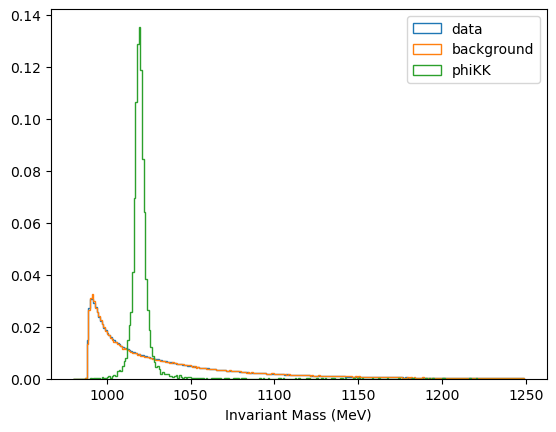

In [58]:
plt.hist(df_data["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data', density=True)
plt.hist(df_bkg["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background', density=True)
plt.hist(df_phiKK["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='phiKK', density=True)


plt.legend()
plt.xlabel('Invariant Mass (MeV)')

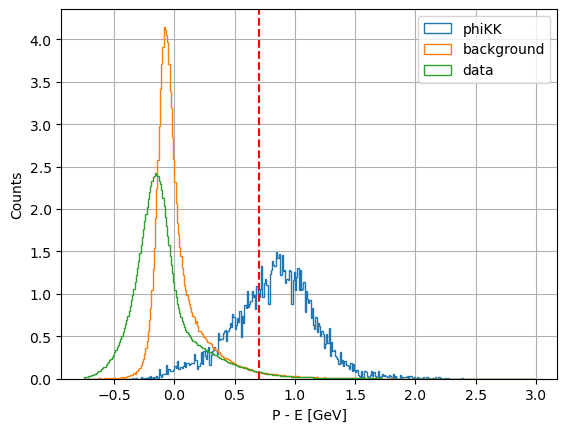

In [124]:
selection1 = 0.7

((df_phiKK.p_Ptot-df_phiKK.pos_E_Ecal)).hist(bins=np.arange(-0.75,3,0.01), density=True, histtype="step",label='phiKK')
((df_bkg.p_Ptot-df_bkg.pos_E_Ecal)).hist(bins=np.arange(-0.75,3,0.01), density=True, histtype="step",label='background')
((df_data.p_Ptot-df_data.pos_E_Ecal)).hist(bins=np.arange(-0.75,3,0.01), density=True, histtype="step",label='data')


plt.axvline(selection1, color='red', linestyle='--')
plt.xlabel('P - E [GeV]')
plt.ylabel('Counts')
plt.legend()

In [125]:
df_data_select1 = df_data.loc[ ((df_data.p_Ptot-df_data.pos_E_Ecal) > selection1 ) ].reset_index(drop=True)
df_phiKK_select1 = df_phiKK.loc[ ((df_phiKK.p_Ptot-df_phiKK.pos_E_Ecal) > selection1 ) ].reset_index(drop=True)
df_bkg_select1 = df_bkg.loc[ ((df_bkg.p_Ptot-df_bkg.pos_E_Ecal) > selection1 ) ].reset_index(drop=True)


Text(0.5, 0, 'Invariant Mass (MeV)')

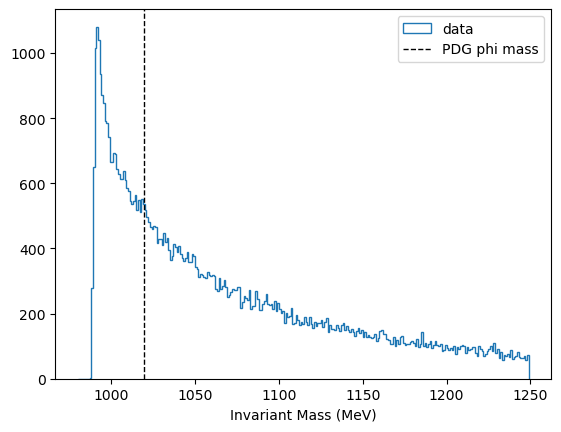

In [126]:

plt.hist(df_data_select1["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0, 0.5, 'Normalized Counts')

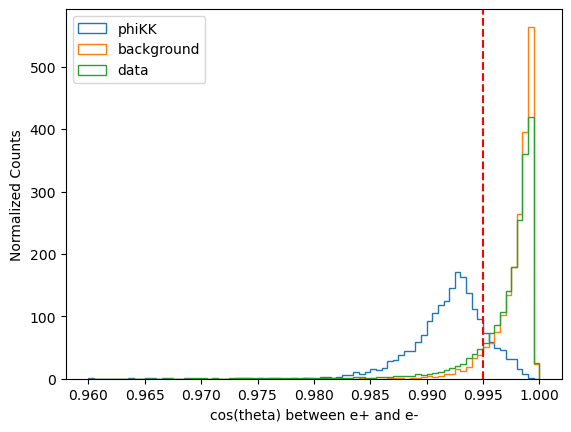

In [127]:
selection2 = 0.995

plt.hist(df_phiKK_select1['cos_theta'], bins=np.arange(0.96,1,0.0005), histtype='step', label='phiKK', density=True)
plt.hist(df_bkg_select1['cos_theta'], bins=np.arange(0.96,1,0.0005), histtype='step', label='background', density=True)
plt.hist(df_data_select1['cos_theta'], bins=np.arange(0.96,1,0.0005), histtype='step', label='data', density=True)
plt.axvline(selection2, color='red', linestyle='--')


plt.legend()
plt.xlabel('cos(theta) between e+ and e-')
plt.ylabel('Normalized Counts')

In [128]:
df_data_select2 = df_data_select1.loc[ ( df_data_select1['cos_theta'] < selection2 ) ].reset_index(drop=True)
df_phiKK_select2 = df_phiKK_select1.loc[ ( df_phiKK_select1['cos_theta'] < selection2 ) ].reset_index(drop=True)
df_bkg_select2 = df_bkg_select1.loc[ ( df_bkg_select1['cos_theta'] < selection2 ) ].reset_index(drop=True)

Text(0.5, 0, 'Invariant Mass (MeV)')

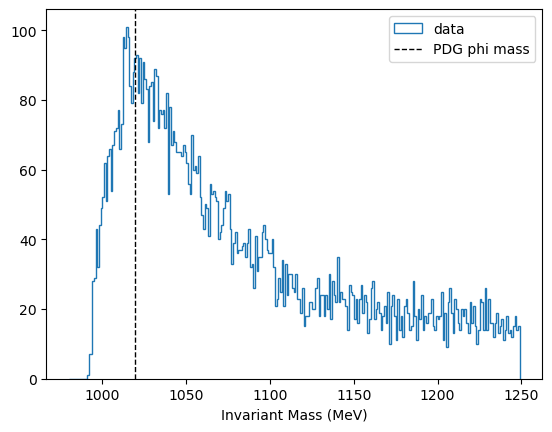

In [129]:

plt.hist(df_data_select2["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

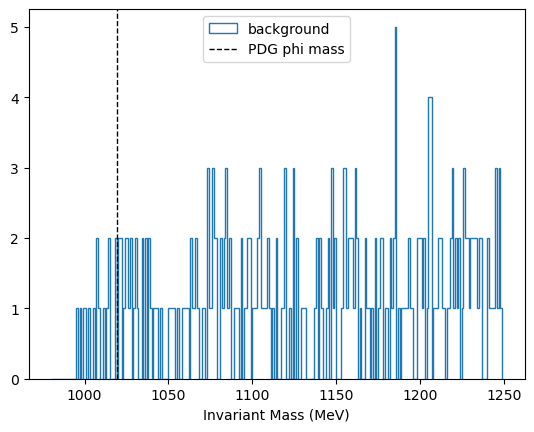

In [130]:

plt.hist(df_bkg_select2["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 1.0, 'ECal Cluster Positions')

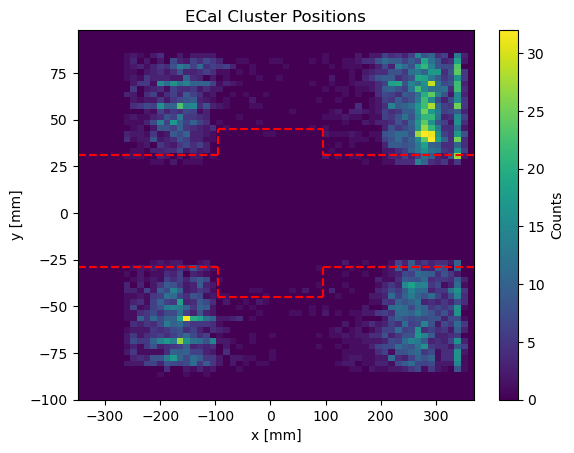

In [131]:
# Create the 2D histogram
plt.hist2d(np.append(df_phiKK_select2.ele_Ecal_x,df_phiKK_select2.pos_Ecal_x) , np.append(df_phiKK_select2.ele_Ecal_y,df_phiKK_select2.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines
point1 = (-350, 31)
point2 = (-95, 31)
point3 = (-95, 45)
point4 = (95, 45)
point5 = (95, 31)
point6 = (4000, 31)

plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point5[0]], [point4[1], point5[1]], color='red', linestyle='--')
plt.plot( [point5[0], point6[0]], [point5[1], point6[1]], color='red', linestyle='--')

point1_bottom = (-350, -29)
point2_bottom = (-95, -29)
point3_bottom = (-95, -45)
point4_bottom = (95, -45)
point5_bottom = (95, -29)
point6_bottom = (4000, -29)

plt.plot( [point1_bottom[0], point2_bottom[0]], [point1_bottom[1], point2_bottom[1]], color='red', linestyle='--')
plt.plot( [point2_bottom[0], point3_bottom[0]], [point2_bottom[1], point3_bottom[1]], color='red', linestyle='--')
plt.plot( [point3_bottom[0], point4_bottom[0]], [point3_bottom[1], point4_bottom[1]], color='red', linestyle='--')
plt.plot( [point4_bottom[0], point5_bottom[0]], [point4_bottom[1], point5_bottom[1]], color='red', linestyle='--')
plt.plot( [point5_bottom[0], point6_bottom[0]], [point5_bottom[1], point6_bottom[1]], color='red', linestyle='--')


# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

Text(0.5, 1.0, 'ECal Cluster Positions')

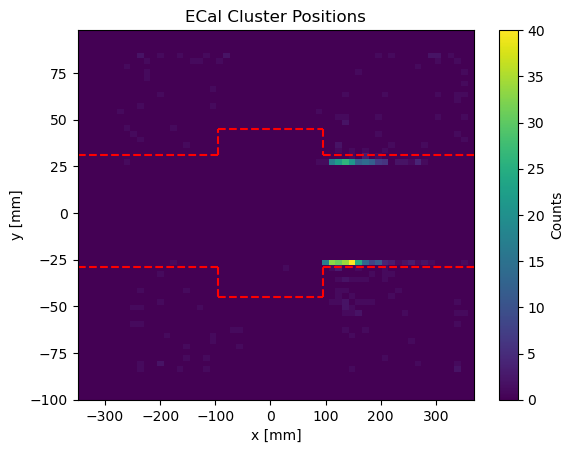

In [132]:
# Create the 2D histogram
plt.hist2d(np.append(df_bkg_select2.ele_Ecal_x,df_bkg_select2.pos_Ecal_x) , np.append(df_bkg_select2.ele_Ecal_y,df_bkg_select2.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines


plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point5[0]], [point4[1], point5[1]], color='red', linestyle='--')
plt.plot( [point5[0], point6[0]], [point5[1], point6[1]], color='red', linestyle='--')


plt.plot( [point1_bottom[0], point2_bottom[0]], [point1_bottom[1], point2_bottom[1]], color='red', linestyle='--')
plt.plot( [point2_bottom[0], point3_bottom[0]], [point2_bottom[1], point3_bottom[1]], color='red', linestyle='--')
plt.plot( [point3_bottom[0], point4_bottom[0]], [point3_bottom[1], point4_bottom[1]], color='red', linestyle='--')
plt.plot( [point4_bottom[0], point5_bottom[0]], [point4_bottom[1], point5_bottom[1]], color='red', linestyle='--')
plt.plot( [point5_bottom[0], point6_bottom[0]], [point5_bottom[1], point6_bottom[1]], color='red', linestyle='--')


# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

Text(0.5, 1.0, 'ECal Cluster Positions')

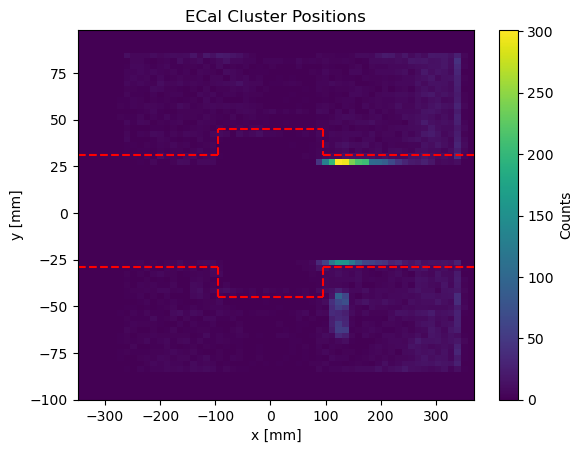

In [133]:
# Create the 2D histogram
plt.hist2d(np.append(df_data_select2.ele_Ecal_x,df_data_select2.pos_Ecal_x) , np.append(df_data_select2.ele_Ecal_y,df_data_select2.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines


plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point5[0]], [point4[1], point5[1]], color='red', linestyle='--')
plt.plot( [point5[0], point6[0]], [point5[1], point6[1]], color='red', linestyle='--')



plt.plot( [point1_bottom[0], point2_bottom[0]], [point1_bottom[1], point2_bottom[1]], color='red', linestyle='--')
plt.plot( [point2_bottom[0], point3_bottom[0]], [point2_bottom[1], point3_bottom[1]], color='red', linestyle='--')
plt.plot( [point3_bottom[0], point4_bottom[0]], [point3_bottom[1], point4_bottom[1]], color='red', linestyle='--')
plt.plot( [point4_bottom[0], point5_bottom[0]], [point4_bottom[1], point5_bottom[1]], color='red', linestyle='--')
plt.plot( [point5_bottom[0], point6_bottom[0]], [point5_bottom[1], point6_bottom[1]], color='red', linestyle='--')


# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

In [134]:
df_data_select3a = df_data_select2.loc[ ~(( (df_data_select2.ele_Ecal_y < point1[1]) & (df_data_select2.ele_Ecal_y > point1_bottom[1])) | ( (df_data_select2.ele_Ecal_y < point3[1]) & (df_data_select2.ele_Ecal_y > point3_bottom[1] ) & (df_data_select2.ele_Ecal_x > point2[0] ) & (df_data_select2.ele_Ecal_x < point4[0]) ))  ].reset_index(drop=True)
df_data_select3 = df_data_select3a.loc[ ~(( (df_data_select3a.pos_Ecal_y < point1[1]) & (df_data_select3a.pos_Ecal_y > point1_bottom[1])) | ( (df_data_select3a.pos_Ecal_y < point3[1]) & (df_data_select3a.pos_Ecal_y > point3_bottom[1] ) & (df_data_select3a.pos_Ecal_x > point2[0] ) & (df_data_select3a.pos_Ecal_x < point4[0]) ))  ].reset_index(drop=True)

df_phiKK_select3a = df_phiKK_select2.loc[ ~(( (df_phiKK_select2.ele_Ecal_y < point1[1]) & (df_phiKK_select2.ele_Ecal_y > point1_bottom[1])) | ( (df_phiKK_select2.ele_Ecal_y < point3[1]) & (df_phiKK_select2.ele_Ecal_y > point3_bottom[1] ) & (df_phiKK_select2.ele_Ecal_x > point2[0] ) & (df_phiKK_select2.ele_Ecal_x < point4[0]) ))  ].reset_index(drop=True)
df_phiKK_select3 = df_phiKK_select3a.loc[ ~(( (df_phiKK_select3a.pos_Ecal_y < point1[1]) & (df_phiKK_select3a.pos_Ecal_y > point1_bottom[1])) | ( (df_phiKK_select3a.pos_Ecal_y < point3[1]) & (df_phiKK_select3a.pos_Ecal_y > point3_bottom[1] ) & (df_phiKK_select3a.pos_Ecal_x > point2[0] ) & (df_phiKK_select3a.pos_Ecal_x < point4[0]) ))  ].reset_index(drop=True)

df_bkg_select3a = df_bkg_select2.loc[ ~(( (df_bkg_select2.ele_Ecal_y < point1[1]) & (df_bkg_select2.ele_Ecal_y > point1_bottom[1])) | ( (df_bkg_select2.ele_Ecal_y < point3[1]) & (df_bkg_select2.ele_Ecal_y > point3_bottom[1] ) & (df_bkg_select2.ele_Ecal_x > point2[0] ) & (df_bkg_select2.ele_Ecal_x < point4[0]) ))  ].reset_index(drop=True)
df_bkg_select3 = df_bkg_select3a.loc[ ~(( (df_bkg_select3a.pos_Ecal_y < point1[1]) & (df_bkg_select3a.pos_Ecal_y > point1_bottom[1])) | ( (df_bkg_select3a.pos_Ecal_y < point3[1]) & (df_bkg_select3a.pos_Ecal_y > point3_bottom[1] ) & (df_bkg_select3a.pos_Ecal_x > point2[0] ) & (df_bkg_select3a.pos_Ecal_x < point4[0]) ))  ].reset_index(drop=True)

Text(0.5, 0, 'Invariant Mass (MeV)')

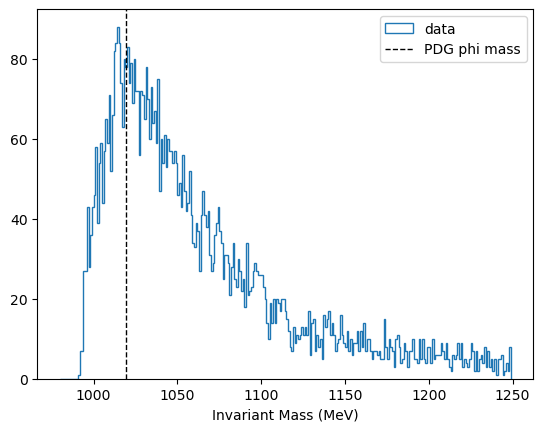

In [135]:
plt.hist(df_data_select3["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

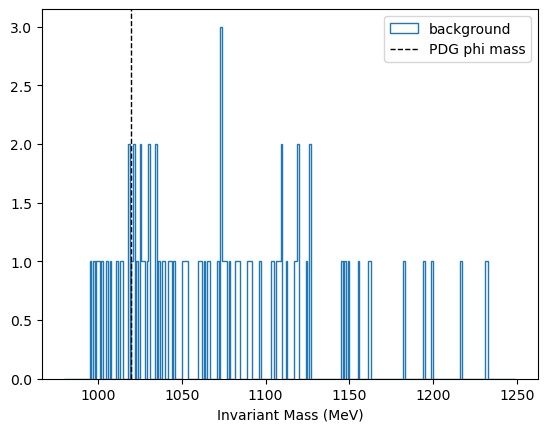

In [136]:
plt.hist(df_bkg_select3["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 1.0, 'ECal Cluster Positions')

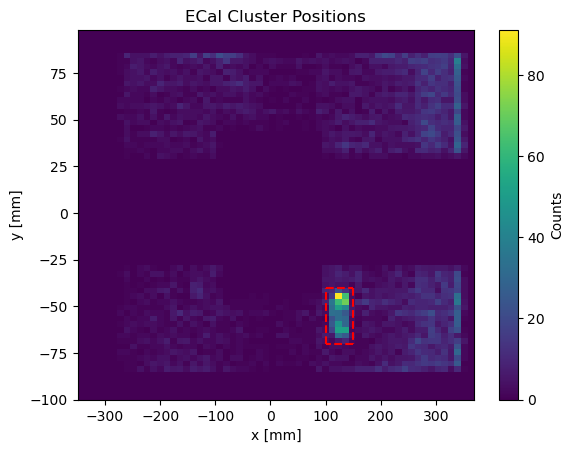

In [137]:
# Create the 2D histogram
plt.hist2d(np.append(df_data_select3.ele_Ecal_x,df_data_select3.pos_Ecal_x) , np.append(df_data_select3.ele_Ecal_y,df_data_select3.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines

point1 = (100, -40)
point2 = (150, -40)
point3 = (150, -70)
point4 = (100, -70)



plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point1[0]], [point4[1], point1[1]], color='red', linestyle='--')



# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

Text(0.5, 1.0, 'ECal Cluster Positions')

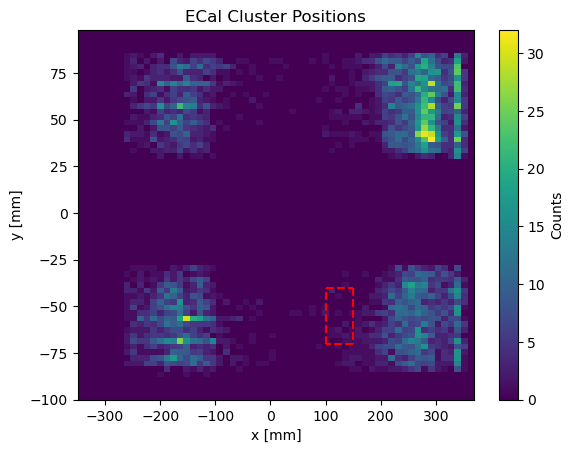

In [138]:
# Create the 2D histogram
plt.hist2d(np.append(df_phiKK_select3.ele_Ecal_x,df_phiKK_select3.pos_Ecal_x) , np.append(df_phiKK_select3.ele_Ecal_y,df_phiKK_select3.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines

point1 = (100, -40)
point2 = (150, -40)
point3 = (150, -70)
point4 = (100, -70)



plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point1[0]], [point4[1], point1[1]], color='red', linestyle='--')



# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

Text(0.5, 1.0, 'ECal Cluster Positions')

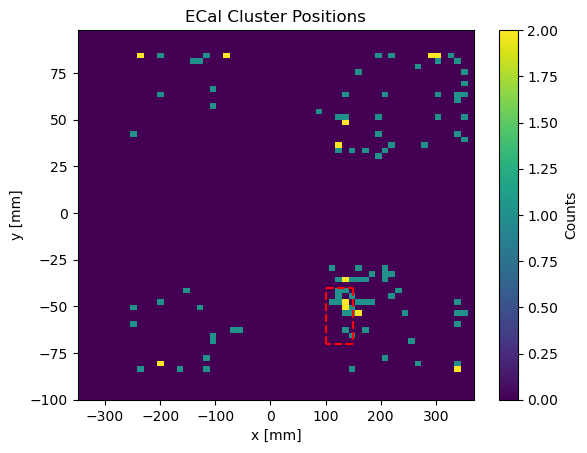

In [139]:
# Create the 2D histogram
plt.hist2d(np.append(df_bkg_select3.ele_Ecal_x,df_bkg_select3.pos_Ecal_x) , np.append(df_bkg_select3.ele_Ecal_y,df_bkg_select3.pos_Ecal_y), bins=[np.arange(-350,380,12),np.arange(-100, 100, 3)], cmap='viridis')

# Add a colorbar
plt.colorbar(label='Counts')


#plot section lines

point1 = (100, -40)
point2 = (150, -40)
point3 = (150, -70)
point4 = (100, -70)



plt.plot( [point1[0], point2[0]], [point1[1], point2[1]], color='red', linestyle='--')
plt.plot( [point2[0], point3[0]], [point2[1], point3[1]], color='red', linestyle='--')
plt.plot( [point3[0], point4[0]], [point3[1], point4[1]], color='red', linestyle='--')
plt.plot( [point4[0], point1[0]], [point4[1], point1[1]], color='red', linestyle='--')



# Add labels and title
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("ECal Cluster Positions")

In [140]:
df_data_select4 = df_data_select3.loc[ ( (df_data_select3.pos_Ecal_y < point1[1]) & (df_data_select3.pos_Ecal_y > point3[1]) & (df_data_select3.pos_Ecal_x > point1[0])  & (df_data_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)
df_data_select4_neg = df_data_select3.loc[ ~( (df_data_select3.pos_Ecal_y < point1[1]) & (df_data_select3.pos_Ecal_y > point3[1]) & (df_data_select3.pos_Ecal_x > point1[0])  & (df_data_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)

df_phiKK_select4 = df_phiKK_select3.loc[ ( (df_phiKK_select3.pos_Ecal_y < point1[1]) & (df_phiKK_select3.pos_Ecal_y > point3[1]) & (df_phiKK_select3.pos_Ecal_x > point1[0])  & (df_phiKK_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)
df_phiKK_select4_neg = df_phiKK_select3.loc[ ~( (df_phiKK_select3.pos_Ecal_y < point1[1]) & (df_phiKK_select3.pos_Ecal_y > point3[1]) & (df_phiKK_select3.pos_Ecal_x > point1[0])  & (df_phiKK_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)

df_bkg_select4 = df_bkg_select3.loc[ ( (df_bkg_select3.pos_Ecal_y < point1[1]) & (df_bkg_select3.pos_Ecal_y > point3[1]) & (df_bkg_select3.pos_Ecal_x > point1[0])  & (df_bkg_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)
df_bkg_select4_neg = df_bkg_select3.loc[ ~( (df_bkg_select3.pos_Ecal_y < point1[1]) & (df_bkg_select3.pos_Ecal_y > point3[1]) & (df_bkg_select3.pos_Ecal_x > point1[0])  & (df_bkg_select3.pos_Ecal_x < point2[0])    )   ].reset_index(drop=True)

Text(0.5, 0, 'Invariant Mass (MeV)')

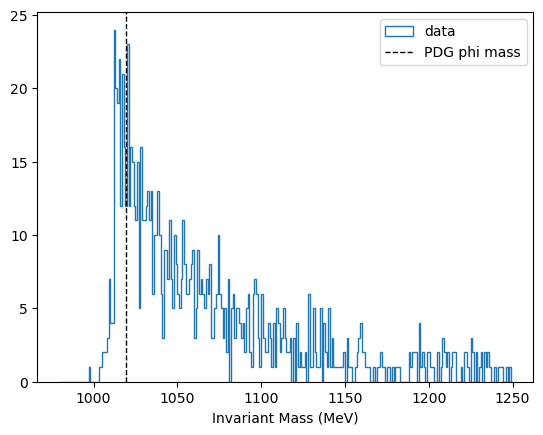

In [141]:
plt.hist(df_data_select4["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

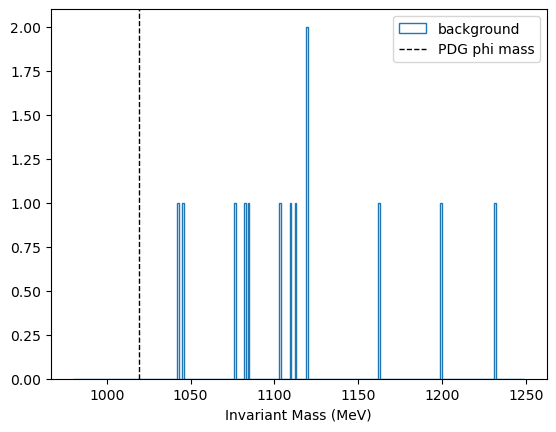

In [142]:
plt.hist(df_bkg_select4["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

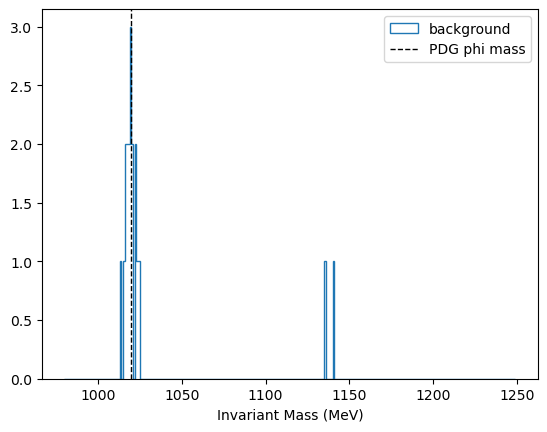

In [143]:
plt.hist(df_phiKK_select4["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

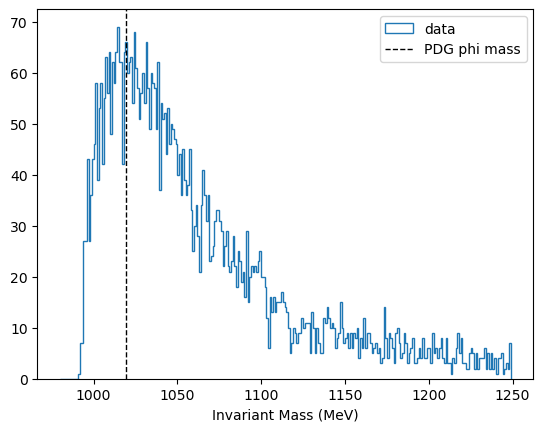

In [144]:
plt.hist(df_data_select4_neg["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='data')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

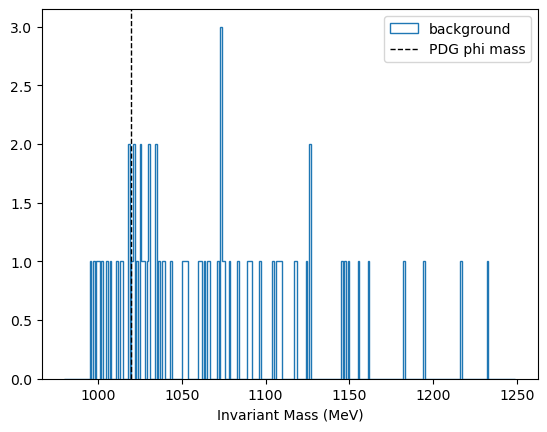

In [145]:
plt.hist(df_bkg_select4_neg["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='background')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')


Text(0.5, 0, 'Invariant Mass (MeV)')

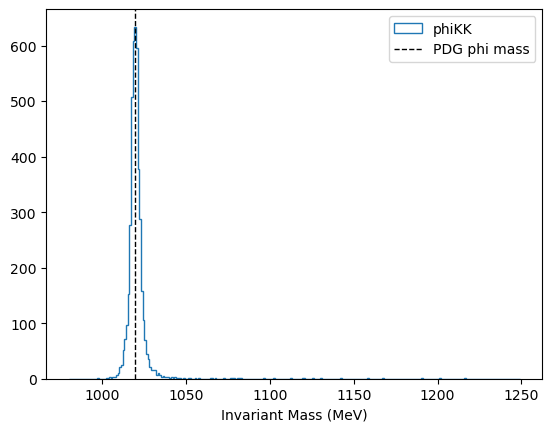

In [146]:
plt.hist(df_phiKK_select4_neg["M"]*1000, bins=np.arange(980,1250,1), histtype='step', label='phiKK')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')


plt.legend()
plt.xlabel('Invariant Mass (MeV)')
